# Módulo 2 — Detección de Fraude
## Notebook 1: Exploración de Datos (EDA)

---

**Contexto de negocio:**  
Una entidad financiera necesita detectar transacciones fraudulentas con tarjeta de crédito en tiempo real.  
El reto principal no es técnico sino estadístico: el fraude es un evento extremadamente raro,  
lo que convierte este problema en uno de los más desafiantes del sector financiero.

**Dataset:** Credit Card Fraud Detection (Kaggle / ULB Machine Learning Group)  
**Observaciones:** 284.807 transacciones  
**Variable objetivo:** `Class` — 0 = legítima · 1 = fraude  

> ⚠️ **Nota sobre el dataset:** Las variables V1–V28 son componentes PCA aplicadas sobre los datos originales  
> por motivos de confidencialidad. Solo `Time`, `Amount` y `Class` conservan su significado original.

---

## 1. Carga de librerías y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


In [2]:
df = pd.read_csv('../../datos/raw/creditcard.csv')

print(f'✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head()

✅ Dataset cargado: 284,807 filas × 31 columnas


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Inspección inicial

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
# Valores nulos
nulos = df.isnull().sum()
print('Valores nulos por columna:')
print(nulos[nulos > 0] if nulos.sum() > 0 else '✅ No hay valores nulos en el dataset')

Valores nulos por columna:
✅ No hay valores nulos en el dataset


## 3. Análisis del desbalance de clases

El primer paso en cualquier problema de detección de anomalías es cuantificar el desbalance.  
En fraude financiero, este desbalance suele ser extremo — y tiene implicaciones críticas para el modelado.

       Clase  Transacciones Porcentaje
Legítima (0)         284315   99.8273%
  Fraude (1)            492    0.1727%


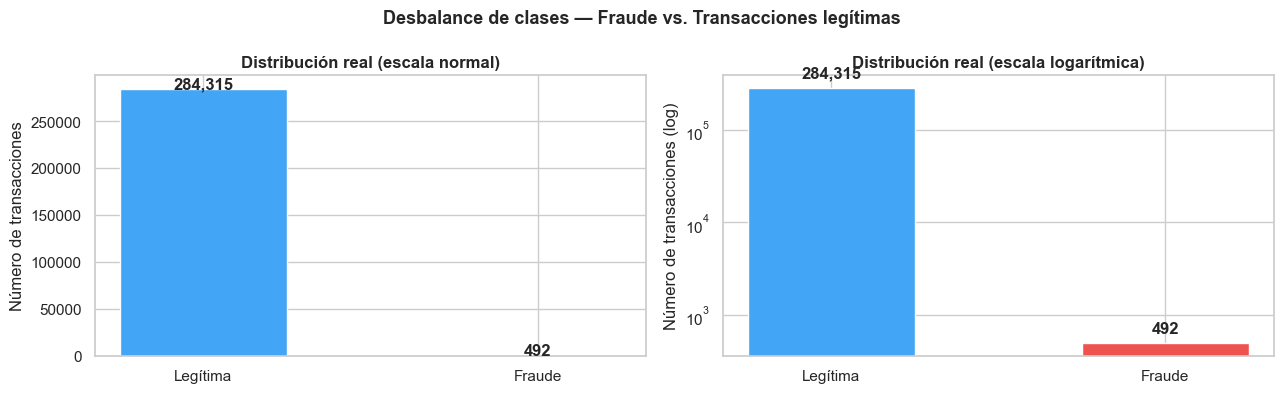

In [5]:
conteo = df['Class'].value_counts()
porcentaje = df['Class'].value_counts(normalize=True) * 100

resumen = pd.DataFrame({
    'Clase': ['Legítima (0)', 'Fraude (1)'],
    'Transacciones': [conteo[0], conteo[1]],
    'Porcentaje': [f"{porcentaje[0]:.4f}%", f"{porcentaje[1]:.4f}%"]
})
print(resumen.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Escala normal — el fraude casi no se ve
axes[0].bar(['Legítima', 'Fraude'], [conteo[0], conteo[1]],
            color=['#42A5F5', '#EF5350'], width=0.5)
axes[0].set_title('Distribución real (escala normal)', fontweight='bold')
axes[0].set_ylabel('Número de transacciones')
for i, v in enumerate([conteo[0], conteo[1]]):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Escala logarítmica — para ver el fraude
axes[1].bar(['Legítima', 'Fraude'], [conteo[0], conteo[1]],
            color=['#42A5F5', '#EF5350'], width=0.5)
axes[1].set_yscale('log')
axes[1].set_title('Distribución real (escala logarítmica)', fontweight='bold')
axes[1].set_ylabel('Número de transacciones (log)')
for i, v in enumerate([conteo[0], conteo[1]]):
    axes[1].text(i, v * 1.3, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Desbalance de clases — Fraude vs. Transacciones legítimas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**💡 Conclusión de negocio:** El fraude representa apenas el ~0.17% de las transacciones. Este desbalance extremo hace que el **accuracy sea una métrica engañosa** — un modelo que prediga siempre "legítima" tendría 99.83% de accuracy y sería completamente inútil. Las métricas relevantes aquí son **Precision**, **Recall** y la **curva Precision-Recall**.

## 4. Análisis del importe de las transacciones

Estadísticas del importe por clase:
             count    mean     std  min   25%    50%     75%       max
Legítima  284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
Fraude       492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


C:\Users\julen\AppData\Local\Temp\ipykernel_6768\1381952765.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([legitimas, fraude], labels=['Legítima', 'Fraude'],


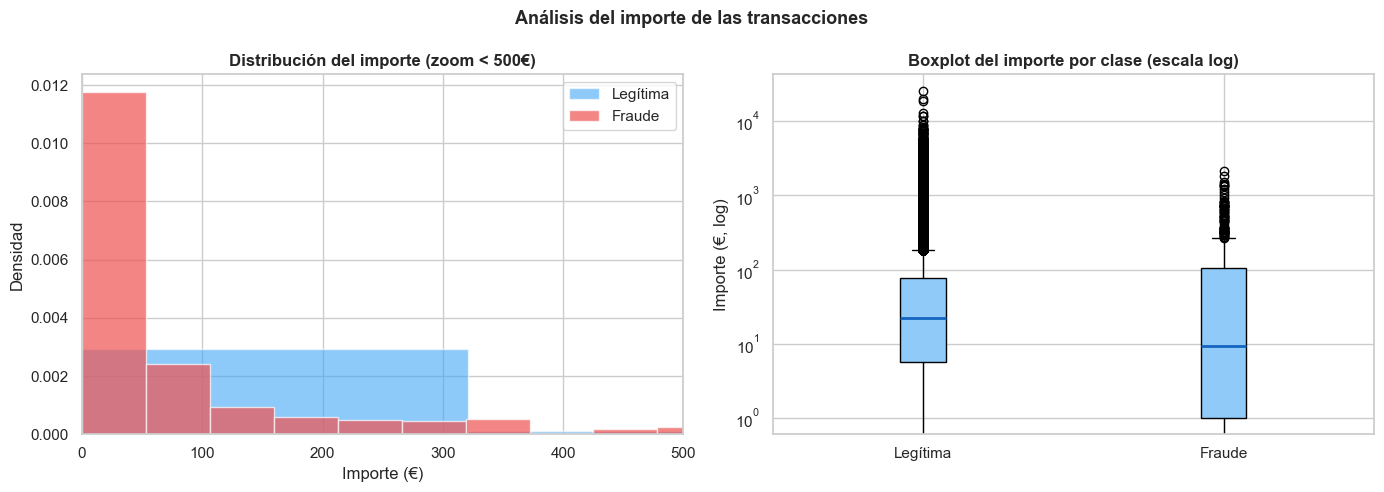

In [6]:
fraude    = df[df['Class'] == 1]['Amount']
legitimas = df[df['Class'] == 0]['Amount']

print('Estadísticas del importe por clase:')
stats = df.groupby('Class')['Amount'].describe().round(2)
stats.index = ['Legítima', 'Fraude']
print(stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de importes
axes[0].hist(legitimas, bins=80, alpha=0.6, color='#42A5F5', label='Legítima', density=True)
axes[0].hist(fraude, bins=40, alpha=0.7, color='#EF5350', label='Fraude', density=True)
axes[0].set_xlim(0, 500)
axes[0].set_title('Distribución del importe (zoom < 500€)', fontweight='bold')
axes[0].set_xlabel('Importe (€)')
axes[0].set_ylabel('Densidad')
axes[0].legend()

# Boxplot comparativo
axes[1].boxplot([legitimas, fraude], labels=['Legítima', 'Fraude'],
                patch_artist=True,
                boxprops=dict(facecolor='#90CAF9'),
                medianprops=dict(color='#1565C0', linewidth=2))
axes[1].set_yscale('log')
axes[1].set_title('Boxplot del importe por clase (escala log)', fontweight='bold')
axes[1].set_ylabel('Importe (€, log)')

plt.suptitle('Análisis del importe de las transacciones', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Análisis temporal

La variable `Time` representa los segundos transcurridos desde la primera transacción del dataset.  
Analizar la distribución temporal del fraude puede revelar patrones horarios relevantes para el negocio.

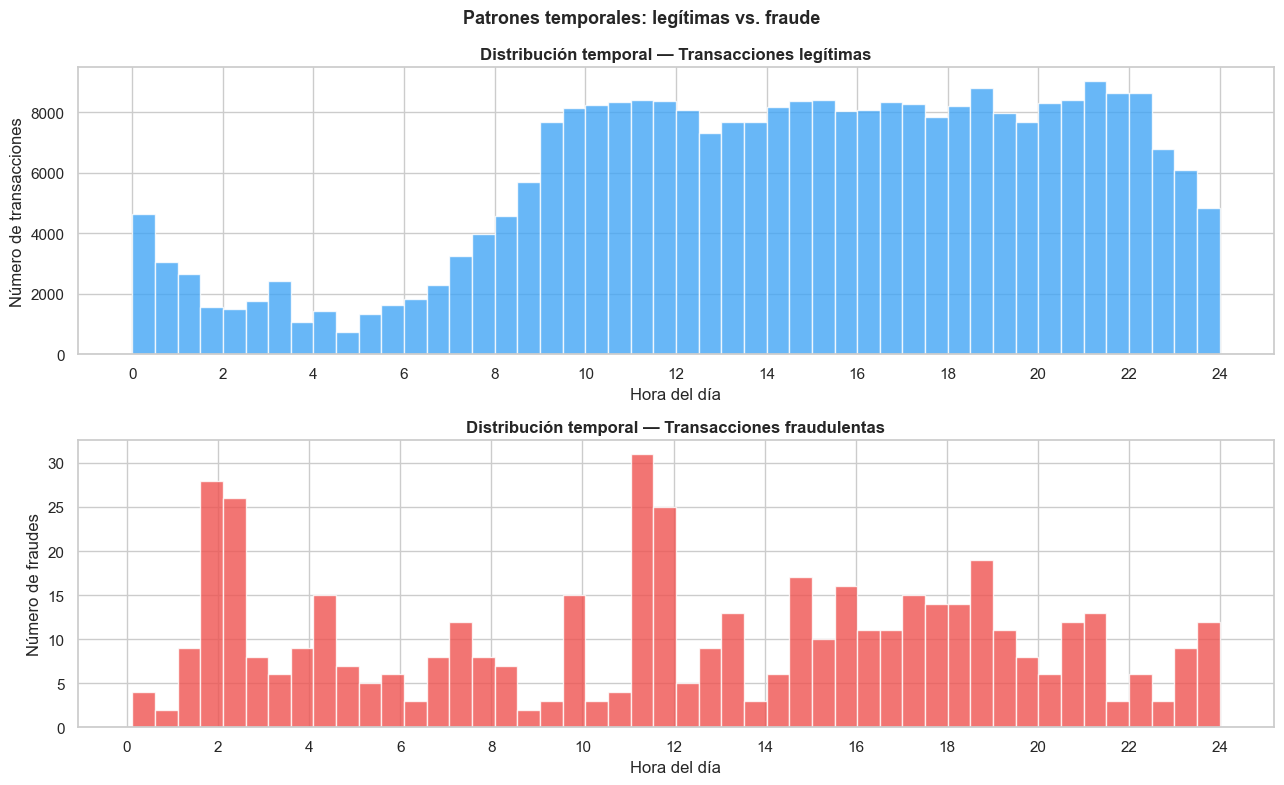

In [7]:
# Convertir segundos a horas para mayor legibilidad
df['hora'] = (df['Time'] / 3600) % 24

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Distribución temporal de transacciones legítimas
axes[0].hist(df[df['Class'] == 0]['hora'], bins=48, color='#42A5F5', alpha=0.8)
axes[0].set_title('Distribución temporal — Transacciones legítimas', fontweight='bold')
axes[0].set_xlabel('Hora del día')
axes[0].set_ylabel('Número de transacciones')
axes[0].set_xticks(range(0, 25, 2))

# Distribución temporal de fraudes
axes[1].hist(df[df['Class'] == 1]['hora'], bins=48, color='#EF5350', alpha=0.8)
axes[1].set_title('Distribución temporal — Transacciones fraudulentas', fontweight='bold')
axes[1].set_xlabel('Hora del día')
axes[1].set_ylabel('Número de fraudes')
axes[1].set_xticks(range(0, 25, 2))

plt.suptitle('Patrones temporales: legítimas vs. fraude', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Análisis de las variables PCA (V1–V28)

Aunque no conocemos el significado original de V1–V28, podemos analizar cuáles muestran  
mayor diferencia entre transacciones legítimas y fraudulentas — estas serán las más útiles para el modelo.

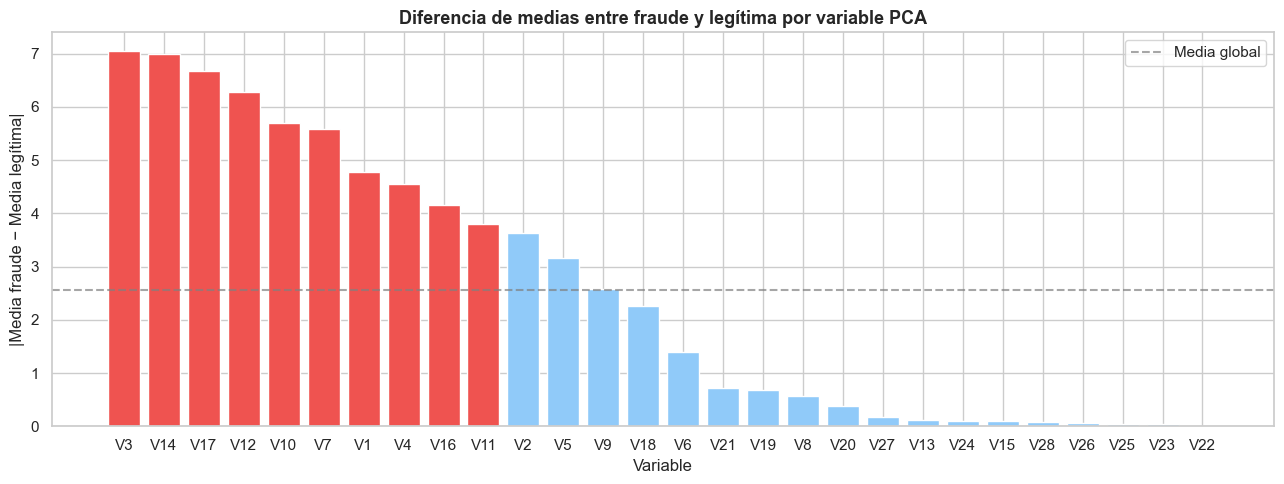

Top 5 variables con mayor diferencia entre clases:
V3     7.045
V14    6.984
V17    6.677
V12    6.270
V10    5.687
dtype: float64


In [8]:
# Diferencia de medias entre clases para cada variable V
vars_v = [f'V{i}' for i in range(1, 29)]

medias_fraude    = df[df['Class'] == 1][vars_v].mean()
medias_legitimas = df[df['Class'] == 0][vars_v].mean()
diferencia = (medias_fraude - medias_legitimas).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
colores = ['#EF5350' if v in diferencia.head(10).index else '#90CAF9' for v in diferencia.index]
ax.bar(diferencia.index, diferencia.values, color=colores)
ax.set_title('Diferencia de medias entre fraude y legítima por variable PCA',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Variable')
ax.set_ylabel('|Media fraude − Media legítima|')
ax.axhline(y=diferencia.mean(), color='gray', linestyle='--',
           alpha=0.7, label='Media global')
ax.legend()
plt.tight_layout()
plt.show()

print('Top 5 variables con mayor diferencia entre clases:')
print(diferencia.head(5).round(3))

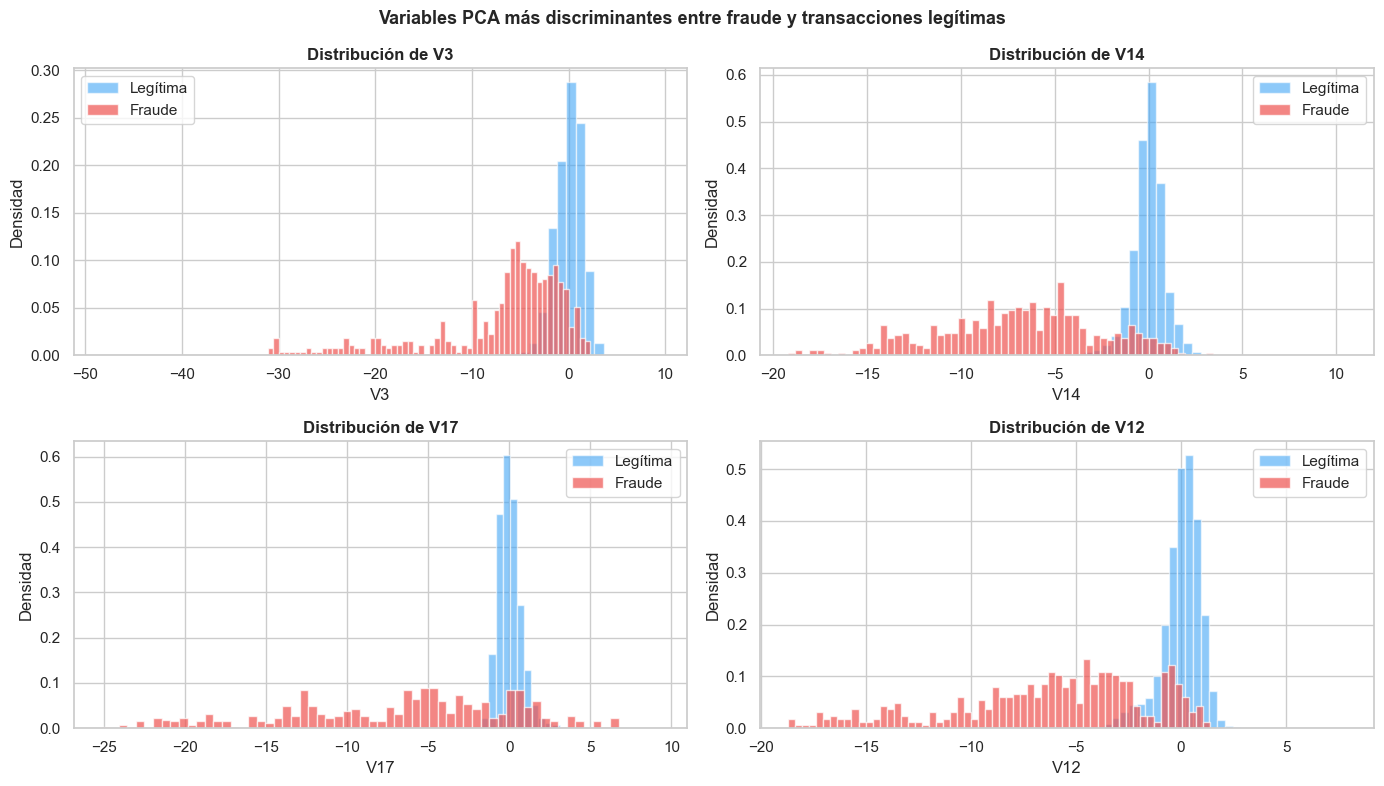

In [9]:
# Distribución de las 4 variables más discriminantes
top4 = diferencia.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, var in enumerate(top4):
    axes[i].hist(df[df['Class'] == 0][var], bins=60, alpha=0.6,
                 color='#42A5F5', label='Legítima', density=True)
    axes[i].hist(df[df['Class'] == 1][var], bins=60, alpha=0.7,
                 color='#EF5350', label='Fraude', density=True)
    axes[i].set_title(f'Distribución de {var}', fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Densidad')
    axes[i].legend()

plt.suptitle('Variables PCA más discriminantes entre fraude y transacciones legítimas',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Conclusiones del EDA

---

### Hallazgos principales

**Sobre el desbalance:**
- Solo el **0.17% de las transacciones son fraude** (492 de 284.807). Este desbalance extremo obliga a usar métricas específicas como Precision, Recall y AUC-PR — el accuracy es completamente engañoso en este contexto.

**Sobre los importes:**
- Las transacciones fraudulentas tienden a ser de **importes más bajos** que las legítimas, lo que sugiere que los defraudadores evitan llamar la atención con montos elevados.
- La mediana del fraude es notablemente inferior a la de transacciones legítimas.

**Sobre los patrones temporales:**
- Las transacciones legítimas siguen un patrón diurno claro con caída nocturna. El fraude, en cambio, presenta una distribución más uniforme a lo largo del día, con una concentración relativa en horas de madrugada — cuando la actividad legítima es mínima.

**Sobre las variables PCA:**
- Las variables con mayor poder discriminante son V4, V11, V12 y V14, con diferencias de medias superiores a 1 punto entre clases. Estas variables serán probablemente las más influyentes en el modelo.

### Implicaciones para el modelo
- El desbalance extremo requiere una estrategia específica: SMOTE agresivo o ajuste de pesos de clase.
- La métrica de evaluación principal será la **curva Precision-Recall**, no el AUC-ROC.
- Se probarán dos enfoques complementarios: detección de anomalías (Isolation Forest) y clasificación supervisada (XGBoost).

